In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2025-02-21 13:09:53.428652: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-21 13:09:53.439477: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740123593.451805   95337 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740123593.455265   95337 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-21 13:09:53.470607: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

### Pre processing

In [2]:
def load_data(filepath):
    data = pd.read_csv(filepath, sep='\t', names=['label', 'text'])
    return data

In [3]:
spam = load_data('dataset/SMSSpamCollection')
df = pd.concat([spam], ignore_index=True)
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# text preprocessing
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])

In [5]:
X = pad_sequences(sequences, maxlen=max_len)
y = df['label'].values

In [6]:
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
train_y = np.where(train_y == 'spam', 1, 0)

In [8]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(4457, 100)
(4457,)
(1115, 100)
(1115,)


In [9]:
print("\nPreprocessing Info:")
print(f"Vocabulary Size: {len(tokenizer.word_index) + 1}")
print(f"Sequence length: {max_len}")
print(f"Total Samples: {len(X)}")


Preprocessing Info:
Vocabulary Size: 9010
Sequence length: 100
Total Samples: 5572


In [10]:
vocab_size = min(len(tokenizer.word_index) + 1, max_words)

In [11]:
inputs = tf.keras.Input(shape=(max_len,))
x = tf.keras.layers.Embedding(vocab_size, 128)(inputs)
x = tf.keras.layers.SimpleRNN(64, return_sequences=True)(x)
x = tf.keras.layers.SimpleRNN(32)(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

I0000 00:00:1740123595.768489   95337 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,001 (2.50 MB)

 Trainable params: 656,001 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [14]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    train_x, train_y,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10


I0000 00:00:1740123597.606380   95422 service.cc:148] XLA service 0x74800c0d8f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1740123597.606400   95422 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-02-21 13:09:57.642635: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1740123597.810922   95422 cuda_dnn.cc:529] Loaded cuDNN version 90300


 15/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8595 - loss: 0.4429

I0000 00:00:1740123599.096912   95422 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8768 - loss: 0.3152 - val_accuracy: 0.9686 - val_loss: 0.1094
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9887 - loss: 0.0618 - val_accuracy: 0.9843 - val_loss: 0.0729
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9957 - loss: 0.0255 - val_accuracy: 0.9809 - val_loss: 0.0973
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9983 - loss: 0.0085 - val_accuracy: 0.9821 - val_loss: 0.1005
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9974 - loss: 0.0096 - val_accuracy: 0.9742 - val_loss: 0.1014


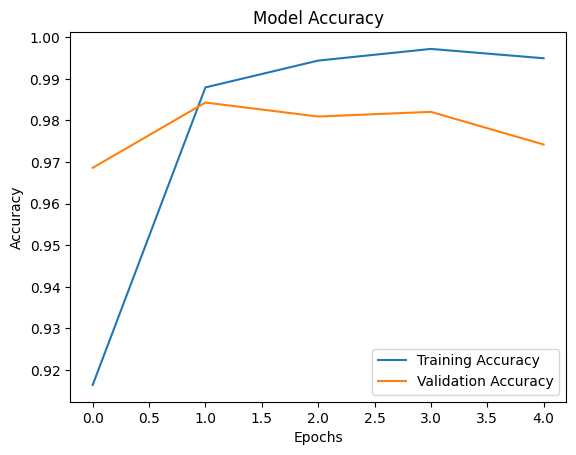

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

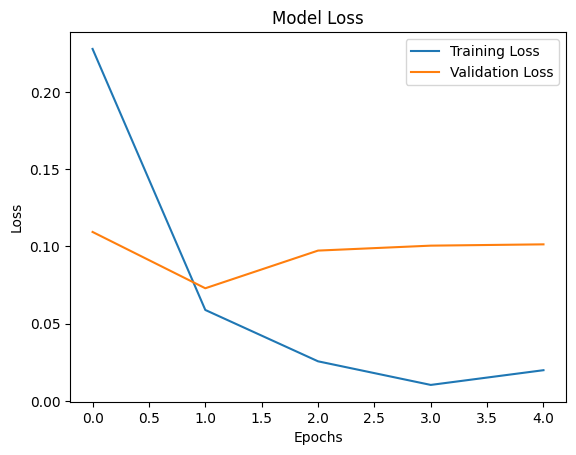

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

In [18]:
def predict_spam(text):
    seq = tokenizer.texts_to_sequences(text)
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model.predict(padded)[0][0]

    return {
        "text": text,
        "Spam": "Positive" if pred > 0.5 else "Negative",
        "confidence": float(pred if pred > 0.5 else 1 - pred)
    }

In [20]:
k = 0
for text in df['text']:
    if(k > 100):
        break
    k += 1
    print(predict_spam(text))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
{'text': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...', 'Spam': 'Negative', 'confidence': 0.9946538805961609}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
{'text': 'Ok lar... Joking wif u oni...', 'Spam': 'Negative', 'confidence': 0.9960715174674988}
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
{'text': "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's", 'Spam': 'Negative', 'confidence': 0.9955745339393616}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
{'text': 'U dun say so early hor... U c already then say...', 'Spam': 'Negative', 'confidence': 0.9963059425354004}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
{'text': "Nah I don't think he goes to usf, he lives around here though", 'Spam': 'Negative', 'confidence': 0.9965617656707764}
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
{'text': "FreeMsg Hey there darl